In [ ]:
import subprocess

def run(cmd, desc=""):
    print(f"⏳ {desc}...")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        print(f"  ⚠️ Error: {r.stderr[-300:]}")
    else:
        print(f"  ✓ Done")
    return r.returncode == 0

# 1. Install build dependencies
run("apt-get install -y build-essential git nasm yasm pkg-config "
    "libfdk-aac-dev libmp3lame-dev libopus-dev > /dev/null 2>&1",
    "Installing build dependencies")

# 2. Download ffmpeg source
run("wget -q -O /tmp/ffmpeg.tar.bz2 "
    "https://ffmpeg.org/releases/ffmpeg-6.1.tar.bz2",
    "Downloading ffmpeg 6.1 source")

# 3. Extract
run("tar -xjf /tmp/ffmpeg.tar.bz2 -C /tmp/", "Extracting source")

# 4. Configure with libfdk_aac + libmp3lame + libopus
run("""cd /tmp/ffmpeg-6.1 && ./configure \
    --prefix=/usr/local \
    --enable-nonfree \
    --enable-libfdk-aac \
    --enable-libmp3lame \
    --enable-libopus \
    --disable-x86asm \
    --quiet > /dev/null 2>&1""",
    "Configuring ffmpeg (this takes ~1 min)")

# 5. Compile — use 2 cores to stay within Colab limits
run("cd /tmp/ffmpeg-6.1 && make -j2 > /dev/null 2>&1",
    "Compiling ffmpeg (this takes ~10-15 min, please wait)")

# 6. Install
run("cd /tmp/ffmpeg-6.1 && make install > /dev/null 2>&1",
    "Installing ffmpeg")

# 7. Verify
r = subprocess.run(["ffmpeg", "-encoders"], capture_output=True, text=True)
if "libfdk_aac" in r.stdout:
    print("\n✅ SUCCESS — libfdk_aac is now available!")
else:
    print("\n❌ libfdk_aac still not found after build.")

r2 = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
print(r2.stdout.split("\n")[0])

⏳ Installing build dependencies...
  ✓ Done
⏳ Downloading ffmpeg 6.1 source...
  ✓ Done
⏳ Extracting source...
  ✓ Done
⏳ Configuring ffmpeg (this takes ~1 min)...
  ✓ Done
⏳ Compiling ffmpeg (this takes ~10-15 min, please wait)...
  ✓ Done
⏳ Installing ffmpeg...
  ✓ Done

✅ SUCCESS — libfdk_aac is now available!
ffmpeg version 6.1 Copyright (c) 2000-2023 the FFmpeg developers


✓ All dependencies installed!

--- Processing MP3 ---
  Encoding MP3 at 8 kbps...
  Encoding MP3 at 12 kbps...
  Encoding MP3 at 24 kbps...
  Encoding MP3 at 48 kbps...
  Encoding MP3 at 64 kbps...

--- Processing AAC (encoder: aac) ---
  Encoding AAC at 8 kbps...
  Encoding AAC at 12 kbps...
  Encoding AAC at 24 kbps...
  Encoding AAC at 48 kbps...
  Encoding AAC at 64 kbps...

--- Processing Opus ---
  Encoding Opus at 8 kbps...
  Encoding Opus at 12 kbps...
  Encoding Opus at 24 kbps...
  Encoding Opus at 48 kbps...
  Encoding Opus at 64 kbps...

Valid bitrates for plotting: [8, 12, 24, 48, 64]

SNR (dB):
  MP3 : [np.float32(19.5), np.float32(20.4), np.float32(20.7), np.float32(21.2), np.float32(23.1)]
  AAC : [np.float32(-2.6), np.float32(-2.9), np.float32(-2.7), np.float32(-2.9), np.float32(-2.9)]
  Opus: [np.float32(7.1), np.float32(14.3), np.float32(18.6), np.float32(22.0), np.float32(22.7)]


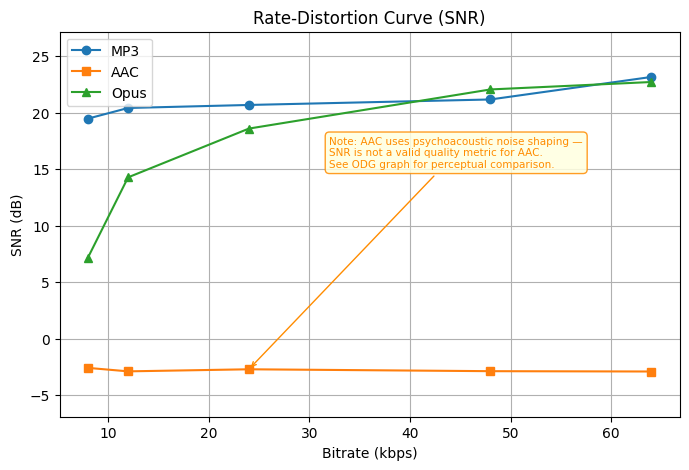


ODG (PESQ-based):
  MP3 : [-0.99, -0.69, -0.74, -0.12, -0.0]
  AAC : [-3.62, -3.6, -1.2, -0.07, 0.0]
  Opus: [-1.47, -0.57, -0.08, 0.0, -0.04]


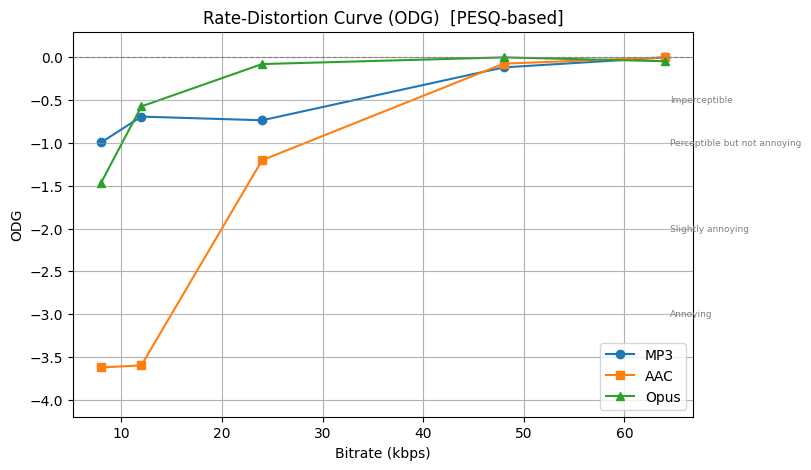


--- Spectrogram Comparison @ 24 kbps ---


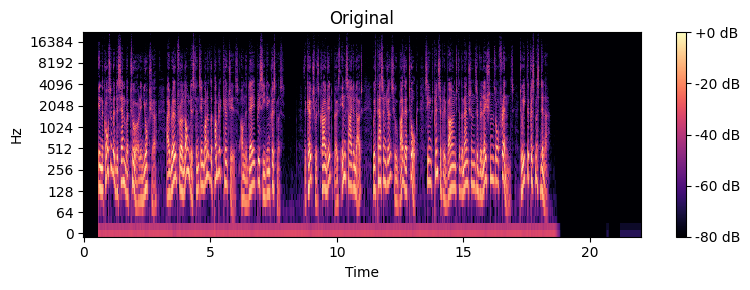

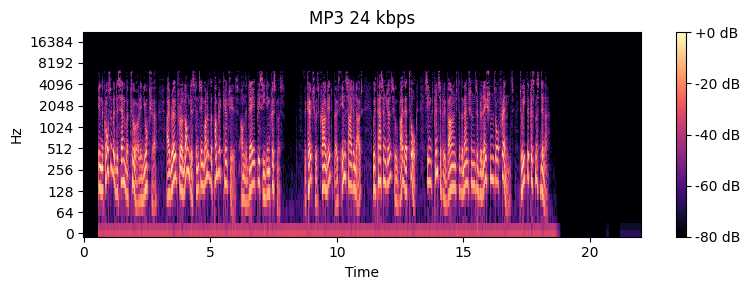

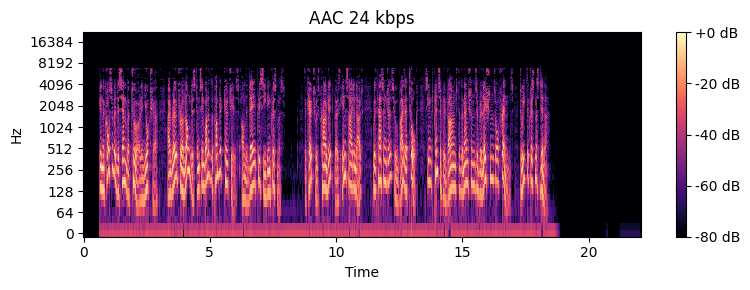

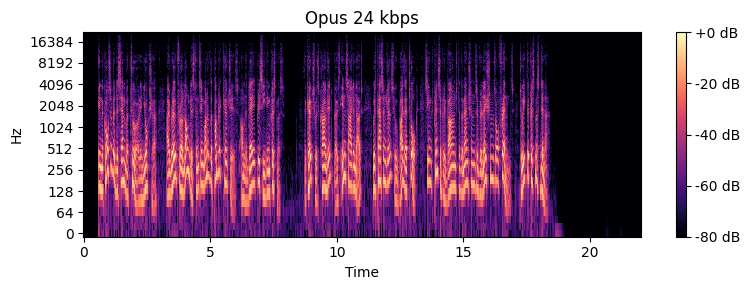


✓ Created codec_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
!pip install pydub numpy scipy matplotlib librosa soundfile pesq --quiet
!apt-get install -y ffmpeg > /dev/null 2>&1
print("✓ All dependencies installed!")

# ============================================================
# IMPORTS
# ============================================================
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import librosa
import librosa.display
from pesq import pesq
from google.colab import files


# ============================================================
# HELPER: ffmpeg encode / decode
# ============================================================
def ffmpeg_encode(input_wav, output_path, codec, bitrate_kbps):
    sample_rate = "48000" if codec == "libopus" else "44100"
    cmd = [
        "ffmpeg", "-y", "-i", input_wav,
        "-c:a", codec,
        "-b:a", f"{bitrate_kbps}k",
        "-ar", sample_rate,
        "-ac", "1",
        output_path
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"  ⚠️  encode error ({codec} {bitrate_kbps}k): {result.stderr[-200:]}")
    return result.returncode == 0


def ffmpeg_decode(encoded_path, output_wav, sample_rate="44100"):
    cmd = [
        "ffmpeg", "-y", "-i", encoded_path,
        "-ar", sample_rate,
        "-ac", "1",
        output_wav
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"  ⚠️  decode error: {result.stderr[-200:]}")
    return result.returncode == 0


# ============================================================
# 1. MP3
# ============================================================
def compress_mp3_sweep(input_wav, bitrates_kbps=[8, 12, 24, 48, 64]):
    print("\n--- Processing MP3 ---")
    recon_files = {}
    for br in bitrates_kbps:
        print(f"  Encoding MP3 at {br} kbps...")
        enc   = f"temp_mp3_{br}.mp3"
        recon = f"recon_mp3_{br}.wav"
        if ffmpeg_encode(input_wav, enc, "libmp3lame", br):
            if ffmpeg_decode(enc, recon):
                recon_files[br] = recon
            os.remove(enc)
        else:
            print(f"  ✗ MP3 {br}k failed, skipping.")
    return recon_files


# ============================================================
# 2. AAC
# ============================================================
def compress_aac_sweep(input_wav, bitrates_kbps=[8, 12, 24, 48, 64]):
    print("\n--- Processing AAC (encoder: aac) ---")
    recon_files = {}
    for br in bitrates_kbps:
        print(f"  Encoding AAC at {br} kbps...")
        enc   = f"temp_aac_{br}.aac"
        recon = f"recon_aac_{br}.wav"
        #if ffmpeg_encode(input_wav, enc, "aac", br):
        if ffmpeg_encode(input_wav, enc, "libfdk_aac", br):
            if ffmpeg_decode(enc, recon):
                recon_files[br] = recon
            os.remove(enc)
        else:
            print(f"  ✗ AAC {br}k failed, skipping.")
    return recon_files


# ============================================================
# 3. OPUS
# ============================================================
def compress_opus_sweep(input_wav, bitrates_kbps=[8, 12, 24, 48, 64]):
    print("\n--- Processing Opus ---")
    recon_files = {}
    for br in bitrates_kbps:
        print(f"  Encoding Opus at {br} kbps...")
        enc   = f"temp_opus_{br}.opus"
        recon = f"recon_opus_{br}.wav"
        if ffmpeg_encode(input_wav, enc, "libopus", br):
            if ffmpeg_decode(enc, recon, sample_rate="44100"):
                recon_files[br] = recon
            os.remove(enc)
        else:
            print(f"  ✗ Opus {br}k failed, skipping.")
    return recon_files


# ============================================================
# 4. METRICS
# ============================================================
def load_and_align(original_file, recon_file, target_sr=16000):
    orig,  _ = librosa.load(original_file, sr=target_sr, mono=True)
    recon, _ = librosa.load(recon_file,    sr=target_sr, mono=True)
    orig  = orig  / (np.max(np.abs(orig))  + 1e-9)
    recon = recon / (np.max(np.abs(recon)) + 1e-9)
    min_len = min(len(orig), len(recon))
    return orig[:min_len], recon[:min_len]


def calculate_snr(original_file, recon_file):
    orig, recon = load_and_align(original_file, recon_file)
    signal_power = np.sum(orig ** 2)
    noise_power  = np.sum((orig - recon) ** 2)
    if noise_power < 1e-12:
        return 60.0
    return 10 * np.log10(signal_power / noise_power)


def calculate_odg(original_file, recon_file):
    """PESQ-WB MOS mapped to ODG [-4, 0]. ODG = (MOS - 4.5) * (4 / 3.5)"""
    orig, recon = load_and_align(original_file, recon_file, target_sr=16000)
    try:
        mos = pesq(16000, orig, recon, 'wb')
    except Exception as e:
        print(f"  ⚠️  PESQ error: {e}")
        return -4.0
    return float(np.clip((mos - 4.5) * (4.0 / 3.5), -4.0, 0.0))


# ============================================================
# 5. PLOTS
# ============================================================
def plot_rd_curve_snr(original_wav, mp3_files, aac_files, opus_files, bitrates):
    mp3_y  = [calculate_snr(original_wav, mp3_files[br])  for br in bitrates]
    aac_y  = [calculate_snr(original_wav, aac_files[br])  for br in bitrates]
    opus_y = [calculate_snr(original_wav, opus_files[br]) for br in bitrates]

    print("\nSNR (dB):")
    print(f"  MP3 : {[round(v,1) for v in mp3_y]}")
    print(f"  AAC : {[round(v,1) for v in aac_y]}")
    print(f"  Opus: {[round(v,1) for v in opus_y]}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(bitrates, mp3_y,  marker='o', label='MP3')
    ax.plot(bitrates, aac_y,  marker='s', label='AAC')
    ax.plot(bitrates, opus_y, marker='^', label='Opus')
    ax.set_xlabel("Bitrate (kbps)")
    ax.set_ylabel("SNR (dB)")
    ax.set_title("Rate-Distortion Curve (SNR)")
    all_y = mp3_y + aac_y + opus_y
    ax.set_ylim(min(all_y) - 4, max(all_y) + 4)
    ax.grid(True)
    ax.legend()

    # Arrow points directly at AAC line at 24 kbps
    ax.annotate(
        "Note: AAC uses psychoacoustic noise shaping —\n"
        "SNR is not a valid quality metric for AAC.\n"
        "See ODG graph for perceptual comparison.",
        xy=(bitrates[2], aac_y[2]),               # tip → AAC at 24 kbps
        xytext=(bitrates[2] + 8, max(all_y) - 8), # text box
        fontsize=7.5,
        color='darkorange',
        bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow',
                  ec='darkorange', alpha=0.85),
        arrowprops=dict(arrowstyle='->', color='darkorange')
    )
    return fig


def plot_rd_curve_odg(original_wav, mp3_files, aac_files, opus_files, bitrates):
    mp3_y  = [calculate_odg(original_wav, mp3_files[br])  for br in bitrates]
    aac_y  = [calculate_odg(original_wav, aac_files[br])  for br in bitrates]
    opus_y = [calculate_odg(original_wav, opus_files[br]) for br in bitrates]

    print("\nODG (PESQ-based):")
    print(f"  MP3 : {[round(v,2) for v in mp3_y]}")
    print(f"  AAC : {[round(v,2) for v in aac_y]}")
    print(f"  Opus: {[round(v,2) for v in opus_y]}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(bitrates, mp3_y,  marker='o', label='MP3')
    ax.plot(bitrates, aac_y,  marker='s', label='AAC')
    ax.plot(bitrates, opus_y, marker='^', label='Opus')
    ax.set_xlabel("Bitrate (kbps)")
    ax.set_ylabel("ODG")
    ax.set_title("Rate-Distortion Curve (ODG)  [PESQ-based]")
    ax.set_ylim(-4.2, 0.3)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

    # ITU-R quality reference lines
    for val, label in [(-0.5, "Imperceptible"),
                        (-1.0, "Perceptible but not annoying"),
                        (-2.0, "Slightly annoying"),
                        (-3.0, "Annoying")]:
        ax.axhline(val, color='lightgray', linewidth=0.5, linestyle=':')
        ax.text(bitrates[-1] + 0.5, val, label,
                fontsize=6.5, va='center', color='gray')

    ax.grid(True)
    ax.legend()
    return fig


# ============================================================
# 6. SPECTROGRAMS
# ============================================================
def plot_spectrogram(file, title, save_path=None):
    y, sr = librosa.load(file, sr=None)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

    plt.figure(figsize=(8, 3))
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


# ============================================================
# 7. RUN
# ============================================================
BITRATES   = [8, 12, 24, 48, 64]
input_file = "test_audio.wav"

mp3_files  = compress_mp3_sweep(input_file,  BITRATES)
aac_files  = compress_aac_sweep(input_file,  BITRATES)
opus_files = compress_opus_sweep(input_file, BITRATES)

valid_bitrates = [br for br in BITRATES
                  if br in mp3_files and br in aac_files and br in opus_files]
print(f"\nValid bitrates for plotting: {valid_bitrates}")

if len(valid_bitrates) == 0:
    print("❌ No valid bitrates — check encode errors above.")
else:
    fig1 = plot_rd_curve_snr(input_file, mp3_files, aac_files, opus_files, valid_bitrates)
    fig1.savefig("rd_curve_snr.png", dpi=300, bbox_inches='tight')
    plt.show()

    fig2 = plot_rd_curve_odg(input_file, mp3_files, aac_files, opus_files, valid_bitrates)
    fig2.savefig("rd_curve_odg.png", dpi=300, bbox_inches='tight')
    plt.show()

    if 24 in valid_bitrates:
        print("\n--- Spectrogram Comparison @ 24 kbps ---")
        plot_spectrogram(input_file, "Original", "spec_original.png")
        plot_spectrogram(mp3_files[24], "MP3 24 kbps", "spec_mp3_24.png")
        plot_spectrogram(aac_files[24], "AAC 24 kbps", "spec_aac_24.png")
        plot_spectrogram(opus_files[24], "Opus 24 kbps", "spec_opus_24.png")

# ============================================================
# 8. ZIP & DOWNLOAD
# ============================================================
zip_filename = "codec_results.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:

    # Add compressed audio files
    for path in mp3_files.values():
        zipf.write(path)

    for path in aac_files.values():
        zipf.write(path)

    for path in opus_files.values():
        zipf.write(path)

    # Add performance plots
    zipf.write("rd_curve_snr.png")
    zipf.write("rd_curve_odg.png")

    # Add spectrograms
    zipf.write("spec_original.png")
    zipf.write("spec_mp3_24.png")
    zipf.write("spec_aac_24.png")
    zipf.write("spec_opus_24.png")

print(f"\n✓ Created {zip_filename}")
files.download(zip_filename)